In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split as ts
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn import svm
from sklearn.svm import SVC
from sklearn.metrics import mean_absolute_percentage_error,r2_score

In [2]:
dataset=pd.read_excel("HousePricePrediction.xlsx")
dataset.shape

(2919, 13)

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


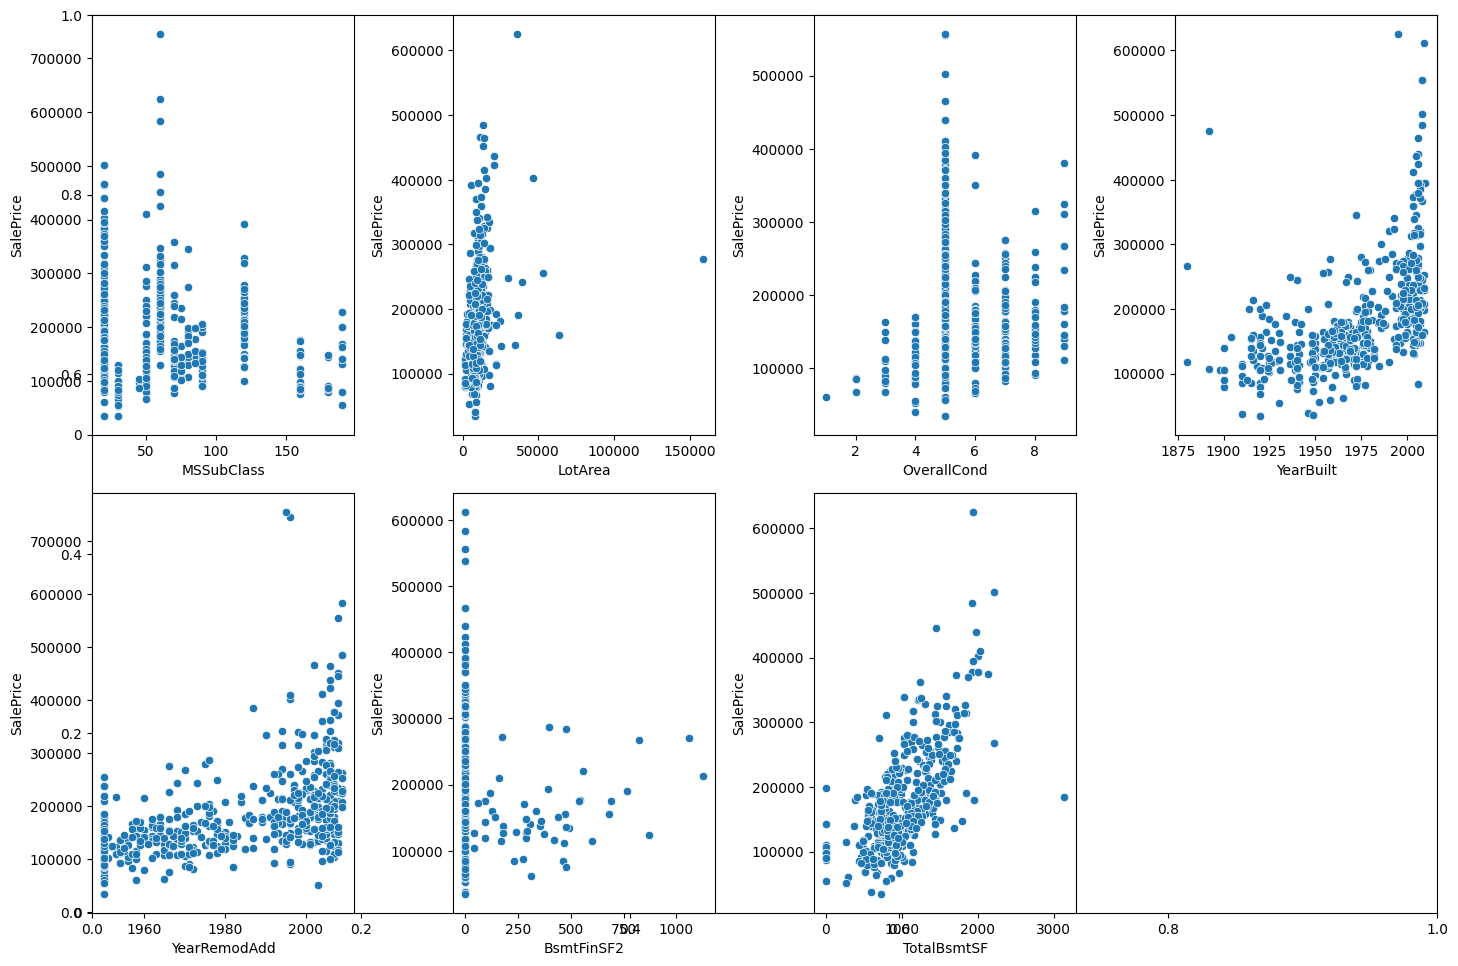

In [4]:
num_features=['MSSubClass','LotArea','OverallCond','YearBuilt','YearRemodAdd','BsmtFinSF2','TotalBsmtSF']
plt.subplots(figsize=(15,10))
for i, col in enumerate(num_features):
    plt.subplot(2,4,i+1)
    x=dataset.sample(1000)
    sb.scatterplot(x=col,y='SalePrice',data=x)
plt.tight_layout()
plt.show()

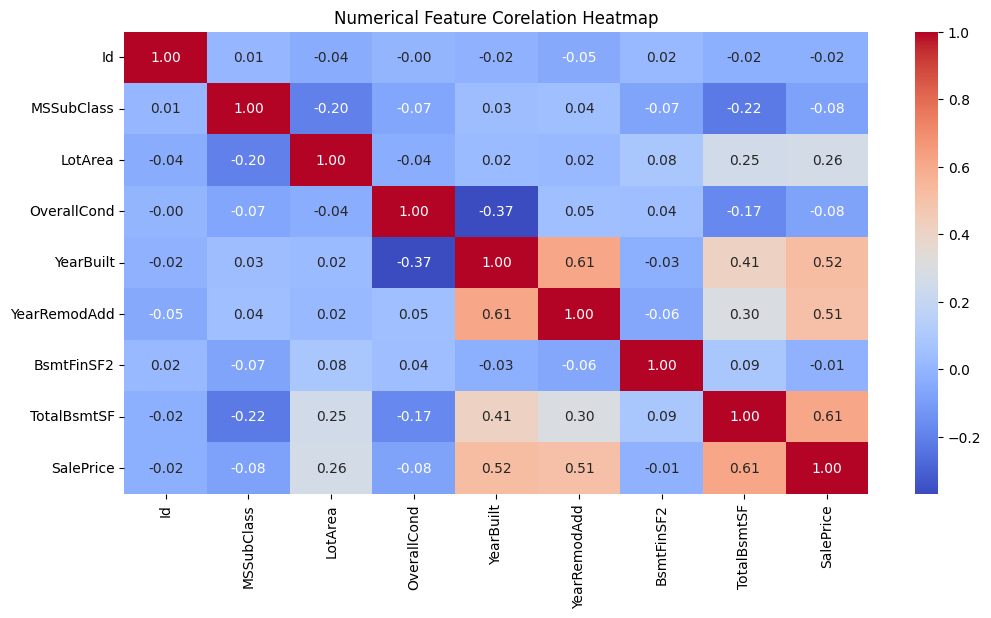

In [5]:
plt.figure(figsize=(12,6))
sb.heatmap(dataset.drop(['MSZoning','LotConfig','BldgType','Exterior1st'], axis=1).corr(),annot=True,cmap="coolwarm",fmt='.2f')
plt.title("Numerical Feature Corelation Heatmap")
plt.show()

In [6]:
dataset.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


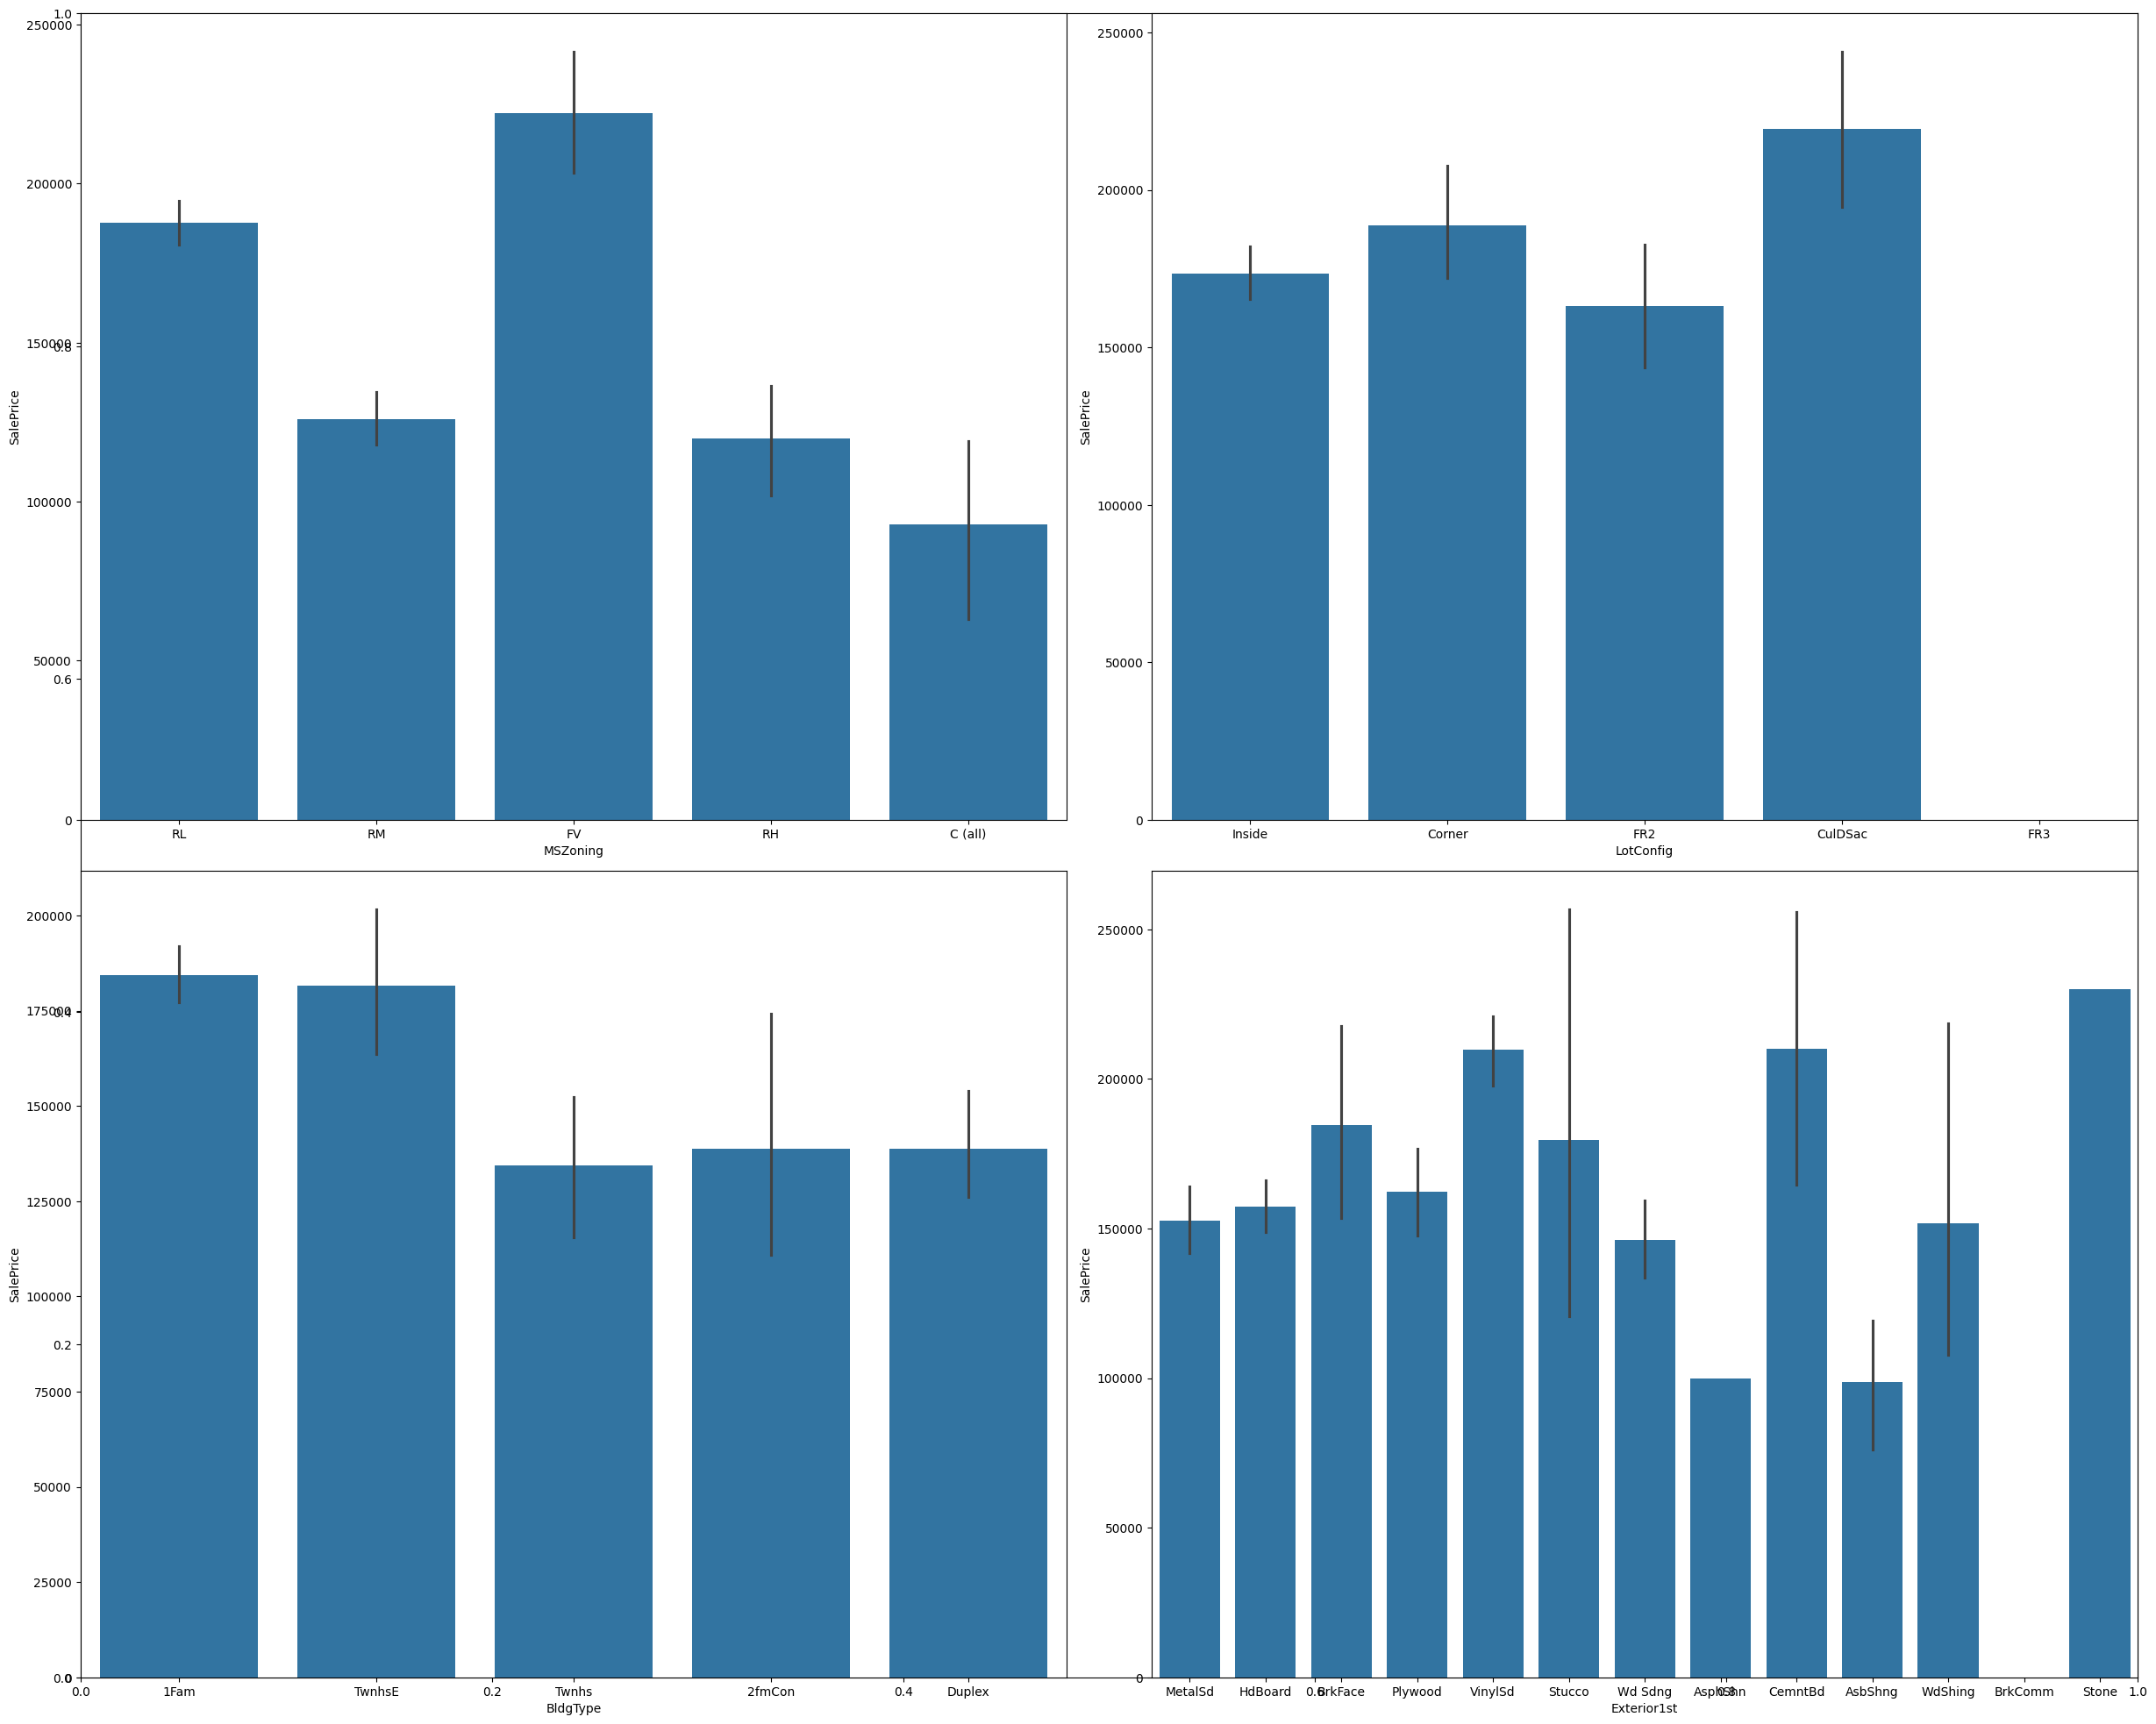

In [7]:
categorical_features=['MSZoning','LotConfig','BldgType','Exterior1st']
plt.subplots(figsize=(25,20))
for i,col in enumerate(categorical_features):
    plt.subplot(2,2,i+1)
    x=dataset.sample(1000)
    sb.barplot(x=col,y='SalePrice',data=x)
plt.tight_layout()
plt.show()

In [8]:
dataset.drop(['Id'],axis=1,inplace=True)

In [9]:
dataset['SalePrice'] = dataset['SalePrice'].fillna(dataset['SalePrice'].mean()) 

In [10]:
new_dataset = dataset.dropna()

In [11]:
new_dataset.isnull().sum()

MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [12]:
new_dataset.head()

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [13]:
s = (new_dataset.dtypes == 'object')
object_cols = list(s[s].index)
print("Categorical variables:")
print(object_cols)
print('No. of. categorical features: ', 
      len(object_cols))

Categorical variables:
['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
No. of. categorical features:  4


In [14]:
OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
OH_cols = pd.DataFrame(OH_encoder.fit_transform(new_dataset[object_cols]))
OH_cols.index = new_dataset.index
OH_cols.columns = OH_encoder.get_feature_names_out()
df_final = new_dataset.drop(object_cols, axis=1)
df_final = pd.concat([df_final, OH_cols], axis=1)

In [15]:
x = df_final.drop(['SalePrice'], axis=1)
y = df_final['SalePrice']

x_train, x_test, y_train, y_test = ts(x, y, train_size=0.8, test_size=0.2, random_state=0)

In [16]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

In [17]:
model_rfr=RandomForestRegressor()
rfr = RandomForestRegressor(n_estimators=200,random_state=42)
rfr.fit(x_train,y_train)
y_pred_rfr=rfr.predict(x_test)

In [18]:
model_SVR = svm.SVR()
model_SVR.fit(x_train,y_train)
y_pred_svm = model_SVR.predict(x_test)

In [19]:
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred_lr=lr.predict(x_test)

In [20]:
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Random Forest R2:", r2_score(y_test, y_pred_rfr))

print("Linear MAPE:", mean_absolute_percentage_error(y_test, y_pred_lr))
print("Random Forest MAPE:", mean_absolute_percentage_error(y_test, y_pred_rfr))
print("SVM MAPE Score:", mean_absolute_percentage_error(y_test,y_pred_svm))
print("SVM R2 Score:", r2_score(y_test, y_pred_svm))

Linear Regression R2: 0.38695679229004354
Random Forest R2: 0.29117679533563623
Linear MAPE: 0.18553138386713436
Random Forest MAPE: 0.18867748423875416
SVM MAPE Score: 0.18705106022458629
SVM R2 Score: 8.275152683645537e-06


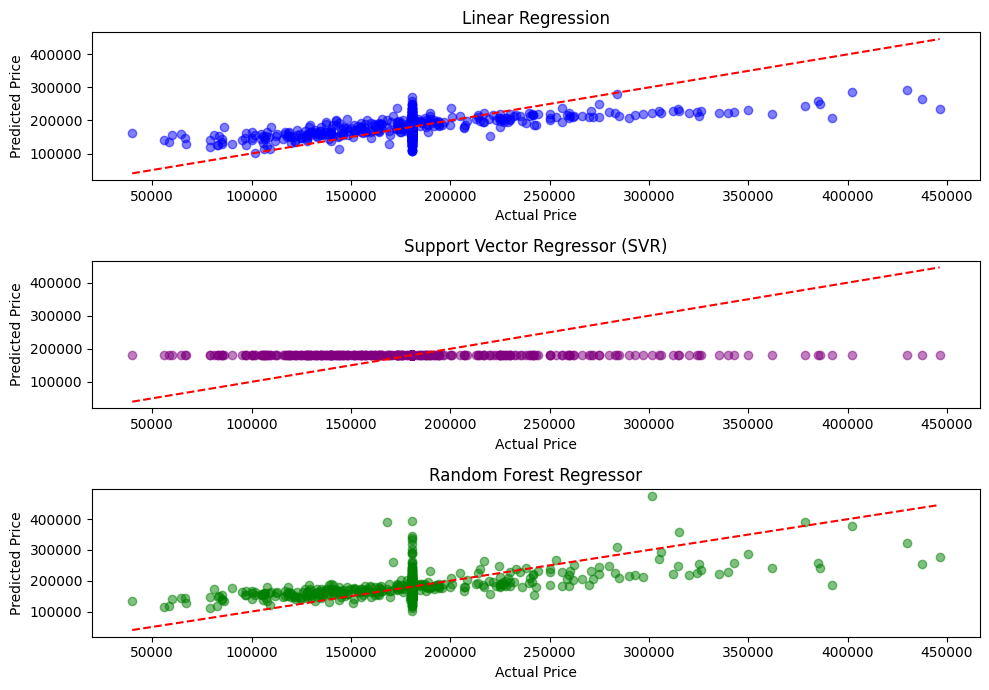

In [21]:
y_pred_lr = lr.predict(x_test)
y_pred_rfr = rfr.predict(x_test)
y_pred_svm = model_SVR.predict(x_test)

plt.figure(figsize=(10, 7))

# Linear Regression subplot
plt.subplot(3, 1, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Linear Regression')

# SVM subplot
plt.subplot(3, 1, 2)
plt.scatter(y_test, y_pred_svm, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Support Vector Regressor (SVR)')

# Random Forest subplot
plt.subplot(3, 1, 3)
plt.scatter(y_test, y_pred_rfr, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest Regressor')

plt.tight_layout()
plt.show()
